In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import config

try:
    config.assert_data_exists()
    print("✓ Data path:", config.DATA_ROOT)
except FileNotFoundError as e:
    print("✗ Data path error:", e)

import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# Try to load preprocessed data from notebook 02; fall back to raw merged CSV
SPLIT_PATH = config.DATA_PART2_PROCESSED / "part2_train_test_split.pkl"

if SPLIT_PATH.exists():
    print(f"Loading preprocessed split from {SPLIT_PATH}")
    with open(SPLIT_PATH, "rb") as f:
        data = pickle.load(f)
    X_train_raw = data["X_train"]
    X_test_raw = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    categorical_cols = data["categorical_cols"]
    numeric_cols = data["numeric_cols"]
    print(f"  Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}")
else:
    print("⚠️ No preprocessed split found. Run 02_feature_engineering.ipynb first.")
    print(f"  Expected path: {SPLIT_PATH}")
    raise FileNotFoundError(f"Preprocessed split not found at {SPLIT_PATH}")

✓ Data path: /home/hareee234/Dev/sjsu/cmpe188-data
Loading preprocessed split from /home/hareee234/Dev/sjsu/cmpe188-data/part2/processed/part2_train_test_split.pkl
  Train: (400000, 55)  |  Test: (100000, 55)


# 03 — Baseline Models (Part 2: BTS 2023)
**CMPE 188 | Flight Delay Prediction**

Loads the feature-engineered train/test split from notebook 02,
builds a preprocessing pipeline, and trains baseline models:
- **XGBoost**
- **Random Forest**
- Comparison table (accuracy, ROC-AUC, F1)

Note: The Neural Network (MLP) baseline is in `06_neural_network.ipynb`.

## 1. Preprocessing Pipeline

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, f1_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
        ("num", MinMaxScaler(), numeric_cols),
    ]
)

selector = SelectKBest(score_func=chi2, k=80)

# Use a subset for faster baseline (set to None for full data)
BASELINE_SAMPLE = 300_000

if BASELINE_SAMPLE and len(X_train_raw) > BASELINE_SAMPLE:
    idx = np.random.RandomState(42).choice(len(X_train_raw), BASELINE_SAMPLE, replace=False)
    X_train = X_train_raw.iloc[idx].reset_index(drop=True)
    y_tr = y_train.iloc[idx].reset_index(drop=True)
    print(f"Using {BASELINE_SAMPLE:,} train sample")
else:
    X_train = X_train_raw
    y_tr = y_train
    print(f"Using all {len(X_train):,} train rows")

# Use same test sample
if BASELINE_SAMPLE and len(X_test_raw) > BASELINE_SAMPLE:
    idx_t = np.random.RandomState(42).choice(len(X_test_raw), BASELINE_SAMPLE // 4, replace=False)
    X_test = X_test_raw.iloc[idx_t].reset_index(drop=True)
    y_te = y_test.iloc[idx_t].reset_index(drop=True)
else:
    X_test = X_test_raw
    y_te = y_test

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Categorical: {len(categorical_cols)}  |  Numeric: {len(numeric_cols)}")

Using 300,000 train sample
Train: (300000, 55)  |  Test: (100000, 55)
Categorical: 11  |  Numeric: 41


## 2. XGBoost Baseline

In [3]:
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", selector),
    ("classifier", XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
    )),
])

print("Training XGBoost baseline...")
xgb_pipeline.fit(X_train, y_tr)
xgb_pred = xgb_pipeline.predict(X_test)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_acc = accuracy_score(y_te, xgb_pred)
xgb_auc = roc_auc_score(y_te, xgb_proba)
xgb_f1 = f1_score(y_te, xgb_pred)

print(f"XGBoost  |  Accuracy: {xgb_acc:.4f}  |  ROC-AUC: {xgb_auc:.4f}  |  F1: {xgb_f1:.4f}")
print()
print(classification_report(y_te, xgb_pred, target_names=["No Delay", "Delayed"]))

Training XGBoost baseline...


XGBoost  |  Accuracy: 0.8046  |  ROC-AUC: 0.8334  |  F1: 0.6775

              precision    recall  f1-score   support

    No Delay       0.77      0.97      0.86     61776
     Delayed       0.92      0.54      0.68     38224

    accuracy                           0.80    100000
   macro avg       0.84      0.75      0.77    100000
weighted avg       0.83      0.80      0.79    100000



## 3. Random Forest Baseline

In [4]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("selector", selector),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
    )),
])

print("Training Random Forest baseline...")
rf_pipeline.fit(X_train, y_tr)
rf_pred = rf_pipeline.predict(X_test)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]

rf_acc = accuracy_score(y_te, rf_pred)
rf_auc = roc_auc_score(y_te, rf_proba)
rf_f1 = f1_score(y_te, rf_pred)

print(f"Random Forest  |  Accuracy: {rf_acc:.4f}  |  ROC-AUC: {rf_auc:.4f}  |  F1: {rf_f1:.4f}")
print()
print(classification_report(y_te, rf_pred, target_names=["No Delay", "Delayed"]))

Training Random Forest baseline...


Random Forest  |  Accuracy: 0.8027  |  ROC-AUC: 0.8309  |  F1: 0.6612

              precision    recall  f1-score   support

    No Delay       0.76      0.99      0.86     61776
     Delayed       0.96      0.50      0.66     38224

    accuracy                           0.80    100000
   macro avg       0.86      0.75      0.76    100000
weighted avg       0.84      0.80      0.78    100000



## 4. Side-by-Side Results

                        Feature Set Accuracy   ROC-AUC        F1
Model                                                           
XGBoost          enriched + derived  0.80463  0.833375  0.677538
Random Forest    enriched + derived  0.80273  0.830896  0.661217
MLP (see nb 06)  enriched + derived      TBD       TBD       TBD


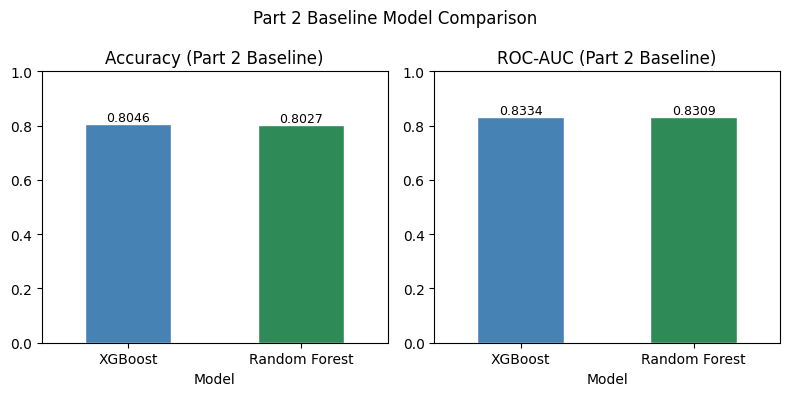

In [5]:
results = pd.DataFrame({
    "Model": ["XGBoost", "Random Forest", "MLP (see nb 06)"],
    "Feature Set": ["enriched + derived", "enriched + derived", "enriched + derived"],
    "Accuracy": [xgb_acc, rf_acc, "TBD"],
    "ROC-AUC": [xgb_auc, rf_auc, "TBD"],
    "F1": [xgb_f1, rf_f1, "TBD"],
})
results = results.set_index("Model")
print(results.to_string())

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_data = results.iloc[:2]  # XGBoost + RF only
for ax, metric in zip(axes, ["Accuracy", "ROC-AUC"]):
    plot_data[metric].plot(kind="bar", ax=ax, color=["steelblue", "seagreen"], edgecolor="white")
    ax.set_title(f"{metric} (Part 2 Baseline)")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=0)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)
plt.suptitle("Part 2 Baseline Model Comparison")
plt.tight_layout()
plt.show()